# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2 transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
from scipy.sparse import hstack, csr_matrix
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cpu


## 1.3 Configuration

In [ ]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata"
RAW_DATA_FILE = "drugreview_heterogeneous_labeled.csv"
OUTPUT_DIR = "outputs"

TEXT_COLUMN0 = "review"
TEXT_COLUMN  = "model_text"
LABEL_COLUMN = "ai_sentiment_5_text_only"
LABEL_COLUMN_ENCODED = "sentiment_Encoded"

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["VERY_NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY_POSITIVE"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "svm":     {"model": OUTPUT_PATH / "best_svm_model.joblib",  "params": OUTPUT_PATH / "best_svm_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": None},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

## 1.4 Load the data

In [ ]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH)
df_raw = df_raw.reset_index(drop=True)
print(f'Loaded {df_raw.shape[0]} rows from {RAW_DATA_PATH}')
df_raw.head()


In [9]:
# R0: the 5-class sentiment label is a direct data column (not derived from aspects).
# Normalize case so it matches CLASS_NAMES (Human labels are lowercase).
df_raw[LABEL_COLUMN] = df_raw[LABEL_COLUMN].astype(str).str.upper().str.strip()
print(f'{LABEL_COLUMN} distribution:')
print(df_raw[LABEL_COLUMN].value_counts())


ai_sentiment_5 distribution:
ai_sentiment_5
POSITIVE         7647
VERY_POSITIVE    6667
VERY_NEGATIVE    5736
NEUTRAL          4441
NEGATIVE         4264
Name: count, dtype: int64


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [10]:
# R0 metadata columns (drug / condition / usefulCount)
df_raw['drug_norm'] = (df_raw['drugName'].fillna('').astype(str).str.lower().str.strip()
                       .str.replace(r'\s+', ' ', regex=True))
if 'condition_clean' in df_raw.columns:
    _cond = df_raw['condition_clean'].where(df_raw['condition_clean'].notna(), df_raw['condition'])
else:
    _cond = df_raw['condition']
df_raw['condition_norm'] = (_cond.fillna('').astype(str).str.lower().str.strip()
                            .str.replace(r'\s+', ' ', regex=True))
df_raw['useful_num'] = pd.to_numeric(df_raw['usefulCount'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.reset_index(drop=True)
df_raw = df_raw[[TEXT_COLUMN0, LABEL_COLUMN, 'drug_norm', 'condition_norm', 'useful_num']]


In [11]:
# DL convention (Manuscript 3): textualize metadata into the model input.
def build_model_text(r):
    return (f"[DRUG] {r['drug_norm']} [COND] {r['condition_norm']} "
            f"[USEFUL] {r['useful_num']} [TEXT] {r[TEXT_COLUMN0]}")

df_raw[TEXT_COLUMN] = df_raw.apply(build_model_text, axis=1)
print(f'{LABEL_COLUMN} distribution:')
print(df_raw[LABEL_COLUMN].value_counts())


ai_sentiment_5 distribution:
ai_sentiment_5
POSITIVE         7647
VERY_POSITIVE    6667
VERY_NEGATIVE    5736
NEUTRAL          4441
NEGATIVE         4264
Name: count, dtype: int64


In [12]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,review,ai_sentiment_5,drug_norm,condition_norm,useful_num,model_text
0,"""After spending years on very high doses of tr...",POSITIVE,tapentadol,pain,25,[DRUG] tapentadol [COND] pain [USEFUL] 25 [TEX...
1,"""Immediate improvements in my joint arthritis ...",VERY_POSITIVE,mobic,rheumatoid arthritis,76,[DRUG] mobic [COND] rheumatoid arthritis [USEF...
2,"""I was taking Atenolol/Chlorthalidone (50mg/12...",NEGATIVE,hydrochlorothiazide / losartan,high blood pressure,18,[DRUG] hydrochlorothiazide / losartan [COND] h...
3,"""I have struggled with acne since I was about ...",NEUTRAL,isotretinoin,acne,3,[DRUG] isotretinoin [COND] acne [USEFUL] 3 [TE...
4,"""There seems to be a lot more negative reviews...",VERY_POSITIVE,etonogestrel,birth control,10,[DRUG] etonogestrel [COND] birth control [USEF...
...,...,...,...,...,...,...
28750,"""Just started my harvoni on day 2. I take it ...",VERY_POSITIVE,ledipasvir / sofosbuvir,hepatitis c,21,[DRUG] ledipasvir / sofosbuvir [COND] hepatiti...
28751,"""I&#039;m a 2 time finisher of the Ironman. Wi...",VERY_POSITIVE,tadalafil,erectile dysfunction,68,[DRUG] tadalafil [COND] erectile dysfunction [...
28752,"""I had the Skyla inserted exactly 2 weeks ago,...",POSITIVE,levonorgestrel,birth control,2,[DRUG] levonorgestrel [COND] birth control [US...
28753,"""I &#039;ve had severe acid reflux for 15 year...",VERY_NEGATIVE,dexilant,gerd,41,[DRUG] dexilant [COND] gerd [USEFUL] 41 [TEXT]...


## 2.2 Master Data Preparation

In [13]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [14]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'VERY_NEGATIVE': 0, 'NEGATIVE': 1, 'NEUTRAL': 2, 'POSITIVE': 3, 'VERY_POSITIVE': 4}
df_clean: 28755 rows


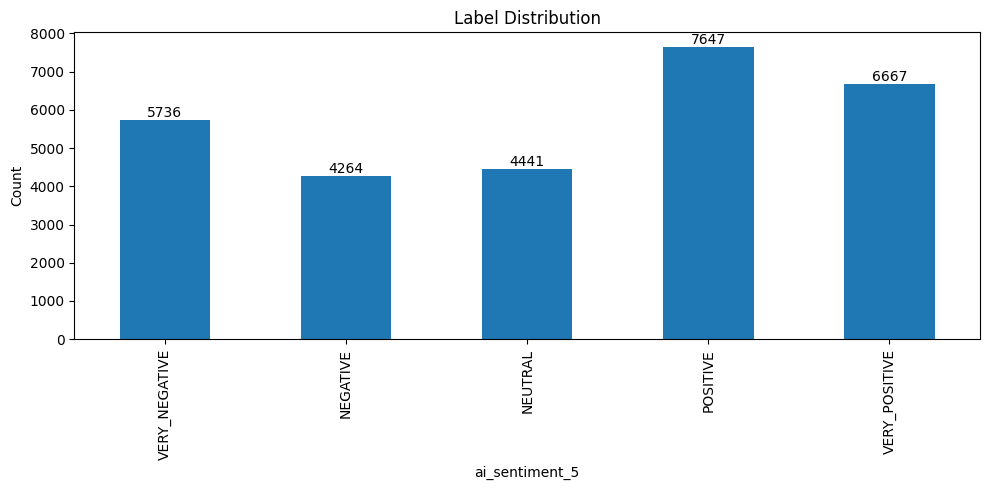

In [15]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [16]:
# --- Group split on the NORMALIZED REVIEW-TEXT key only (Manuscript, Sec. II-G-1):
# --- identical reviews stay in ONE partition even under different metadata.
# --- model_text folds in usefulCount/drug/condition, so grouping on it would leak
# --- duplicate reviews across splits. model_text stays the model INPUT; only the
# --- split grouping uses the review text (matches the text-only notebooks).
df_clean["group_key"] = df_clean[TEXT_COLUMN0].fillna("").astype(str).apply(clean_text)
groups = df_clean["group_key"]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval["group_key"])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby("group_key")["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))


Split counts:
split
train    17243
val       5768
test      5744
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.599652
val      0.200591
test     0.199757
Name: proportion, dtype: float64


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [17]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [18]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [19]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [20]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [21]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [22]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def ml_preprocess(text):
    if not isinstance(text, str):
        return ''
    return ' '.join(lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words)

def safe_str(s):
    return s.fillna('').astype(str).values

df_ml = df_clean.copy()
df_ml['text_ml']      = df_ml[TEXT_COLUMN0].fillna('').astype(str).apply(ml_preprocess)
df_ml['condition_ml'] = df_ml['condition_norm'].fillna('').astype(str).apply(ml_preprocess)
df_ml['drug_ml']      = df_ml['drug_norm'].fillna('').astype(str).apply(ml_preprocess)
df_ml['useful_num']   = pd.to_numeric(df_ml['useful_num'], errors='coerce').fillna(0.0)

df_train_ml = df_ml[df_ml['split'] == 'train'].copy()
df_val_ml   = df_ml[df_ml['split'] == 'val'].copy()
df_test_ml  = df_ml[df_ml['split'] == 'test'].copy()
y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

tfidf_text = TfidfVectorizer(max_features=10000)
tfidf_cond = TfidfVectorizer(max_features=2000)
tfidf_drug = TfidfVectorizer(max_features=2000)
X_train_text_tf = tfidf_text.fit_transform(safe_str(df_train_ml['text_ml']))
X_val_text_tf   = tfidf_text.transform(safe_str(df_val_ml['text_ml']))
X_test_text_tf  = tfidf_text.transform(safe_str(df_test_ml['text_ml']))
X_train_cond_tf = tfidf_cond.fit_transform(safe_str(df_train_ml['condition_ml']))
X_val_cond_tf   = tfidf_cond.transform(safe_str(df_val_ml['condition_ml']))
X_test_cond_tf  = tfidf_cond.transform(safe_str(df_test_ml['condition_ml']))
X_train_drug_tf = tfidf_drug.fit_transform(safe_str(df_train_ml['drug_ml']))
X_val_drug_tf   = tfidf_drug.transform(safe_str(df_val_ml['drug_ml']))
X_test_drug_tf  = tfidf_drug.transform(safe_str(df_test_ml['drug_ml']))
n_train = csr_matrix(df_train_ml['useful_num'].values.reshape(-1, 1))
n_val   = csr_matrix(df_val_ml['useful_num'].values.reshape(-1, 1))
n_test  = csr_matrix(df_test_ml['useful_num'].values.reshape(-1, 1))
X_train_tfidf = hstack([X_train_text_tf, X_train_cond_tf, X_train_drug_tf, n_train], format='csr')
X_val_tfidf   = hstack([X_val_text_tf,   X_val_cond_tf,   X_val_drug_tf,   n_val],   format='csr')
X_test_tfidf  = hstack([X_test_text_tf,  X_test_cond_tf,  X_test_drug_tf,  n_test],  format='csr')
feature_names_tfidf = np.concatenate([
    tfidf_text.get_feature_names_out(),
    np.char.add('cond_', tfidf_cond.get_feature_names_out()),
    np.char.add('drug_', tfidf_drug.get_feature_names_out()),
    np.array(['usefulCount']),
])
print(f'ML features (text+metadata): train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}')


ML features (text+metadata): train=(17243, 11167), val=(5768, 11167), test=(5744, 11167)


## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2", multi_class="multinomial",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.4704 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.5204 | {'C': 1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.5218 | {'C': 1, 'solver': 'lbfgs', 'class_weight': None}
LR tuning: 1058.1s | Best F1=0.5218


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
               precision    recall  f1-score   support

     NEGATIVE     0.3741    0.2643    0.3098       787
      NEUTRAL     0.3646    0.2375    0.2876       901
     POSITIVE     0.4721    0.6224    0.5369      1507
VERY_NEGATIVE     0.6819    0.7403    0.7099      1190
VERY_POSITIVE     0.6437    0.6262    0.6348      1359

     accuracy                         0.5383      5744
    macro avg     0.5073    0.4982    0.4958      5744
 weighted avg     0.5259    0.5383    0.5257      5744

Weighted F1: 0.5257  95% CI [0.5129, 0.5393]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/Logistic_Regression_confusion_matrix.png


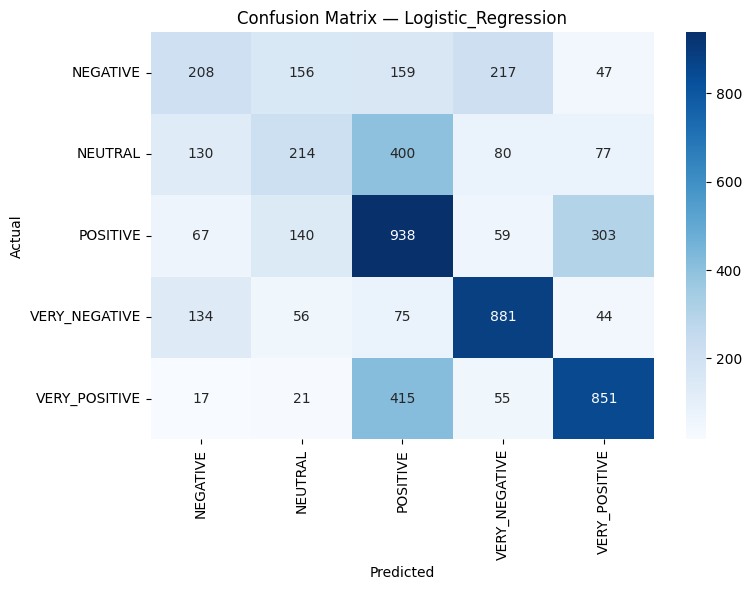

Macro AUC: 0.8264  95% CI [0.8198, 0.8326]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/Logistic_Regression_roc_curve.png


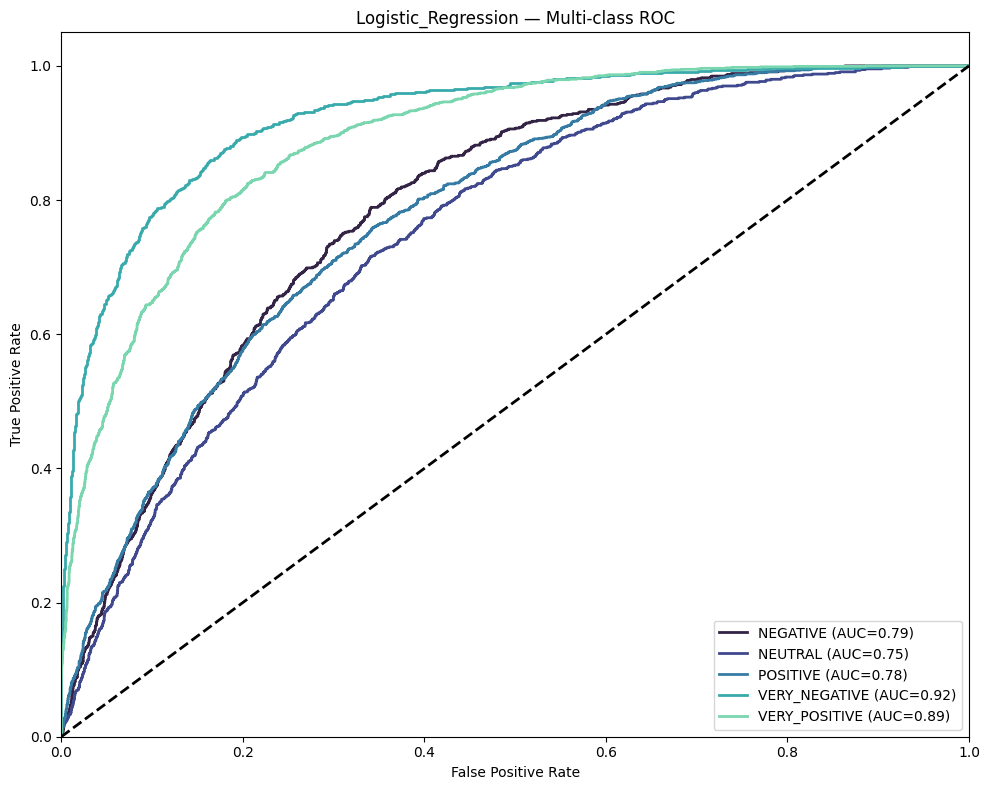

In [24]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/logistic_regression_feature_importance.png


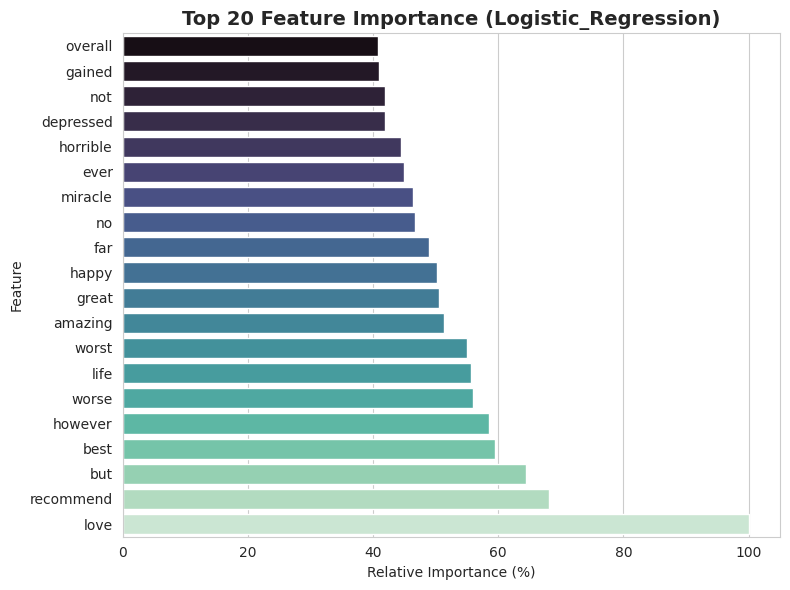

In [25]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 Random Forest

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [07:03<00:00,  2.61s/it]


RF tuning: 423.4s | Best F1=0.4837
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 4, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
               precision    recall  f1-score   support

     NEGATIVE     0.3470    0.3113    0.3282       787
      NEUTRAL     0.3526    0.1898    0.2468       901
     POSITIVE     0.4738    0.4559    0.4647      1507
VERY_NEGATIVE     0.6089    0.7168    0.6584      1190
VERY_POSITIVE     0.5729    0.7174    0.6370      1359

     accuracy                         0.5103      5744
    macro avg     0.4710    0.4782    0.4670      5744
 weighted avg     0.4888    0.5103    0.4927      5744

Weighted F1: 0.4928  95% CI [0.4786, 0.5075]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/RandomForest_confusion_matrix.png


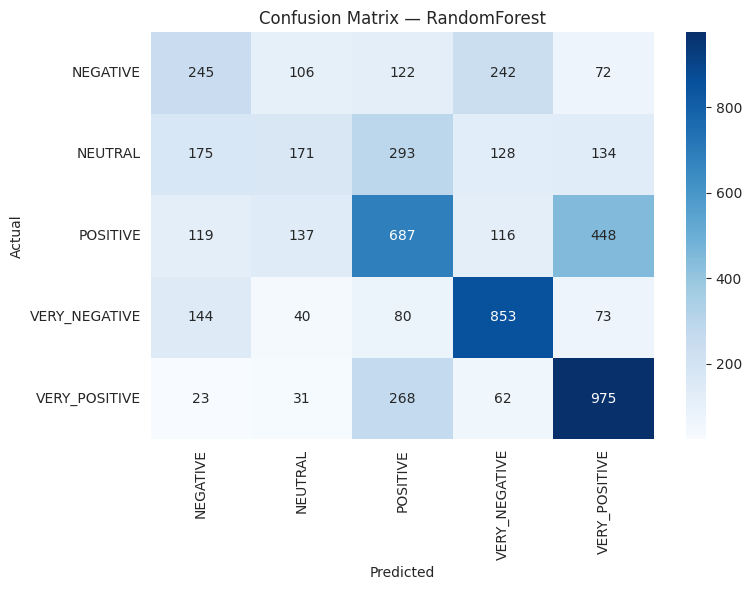

Macro AUC: 0.7991  95% CI [0.7923, 0.8056]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/RandomForest_roc_curve.png


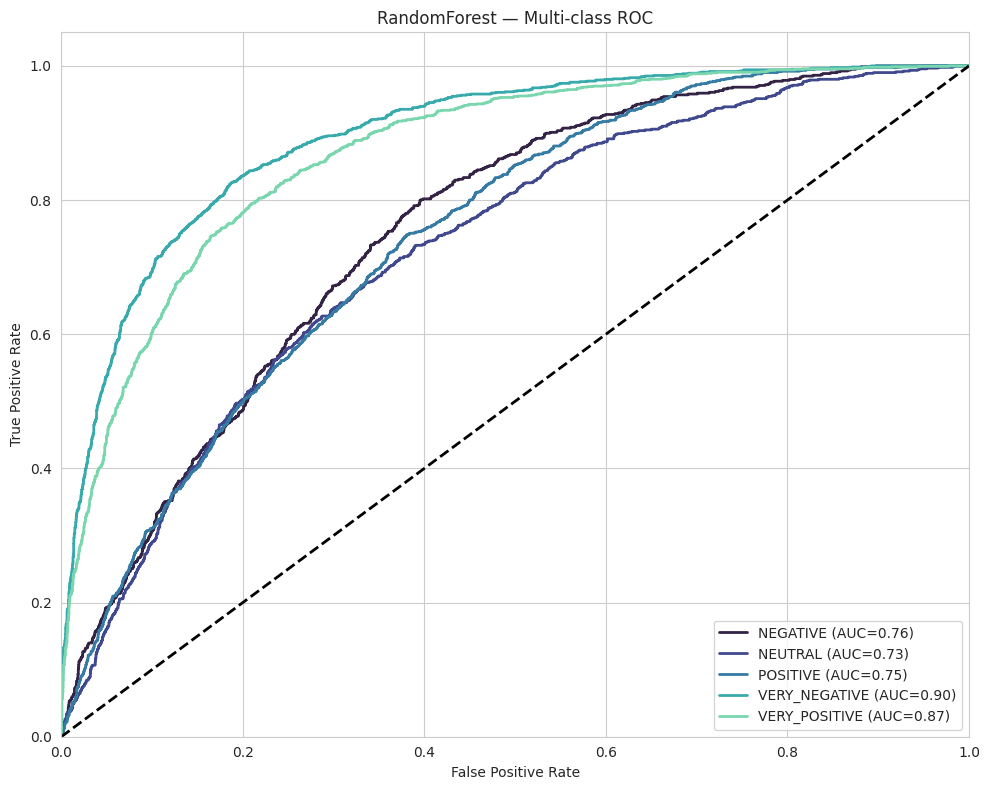

In [27]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/randomforest_feature_importance.png


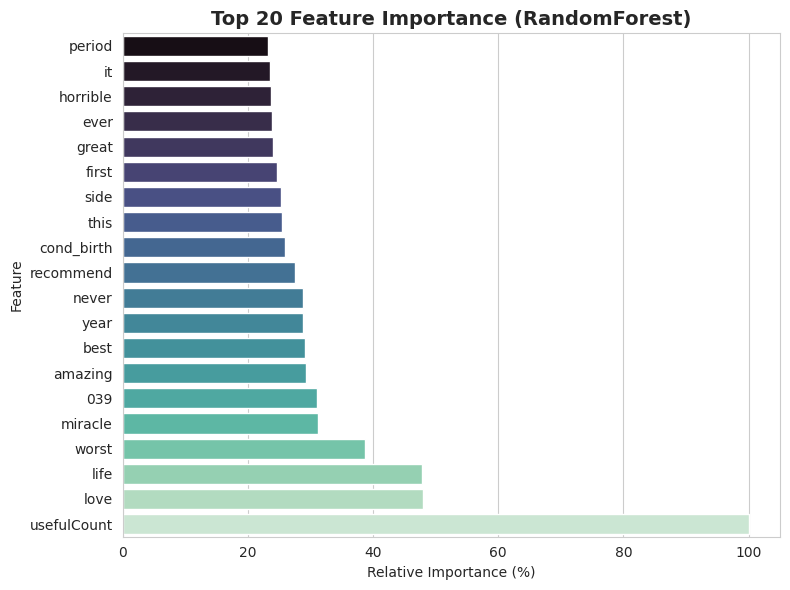

,Feature,Importance,Scaled
11166,usefulCount,0.022915,100.000000
5528,love,0.010995,47.981769
5377,life,0.010961,47.831759
9857,worst,0.008877,38.739803
5809,miracle,0.007158,31.238321
8,039,0.007121,31.074689
1167,amazing,0.006709,29.277249
1702,best,0.006673,29.119108
9927,year,0.006617,28.876121
6045,never,0.006594,28.776303


In [28]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.3 LGBM

### Step 1: Hyperparameter Tuning

In [29]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [30:42<00:00, 38.38s/it]


LGBM tuning: 1842.1s | Best F1=0.5166
Best params: {'n_estimators': 100, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': None, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: LightGBM
               precision    recall  f1-score   support

     NEGATIVE     0.3441    0.3507    0.3474       787
      NEUTRAL     0.3386    0.3330    0.3358       901
     POSITIVE     0.5075    0.4711    0.4886      1507
VERY_NEGATIVE     0.6605    0.6916    0.6757      1190
VERY_POSITIVE     0.6308    0.6549    0.6426      1359

     accuracy                         0.5221      5744
    macro avg     0.4963    0.5003    0.4980      5744
 weighted avg     0.5195    0.5221    0.5205      5744

Weighted F1: 0.5202  95% CI [0.5071, 0.5327]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/LightGBM_confusion_matrix.png


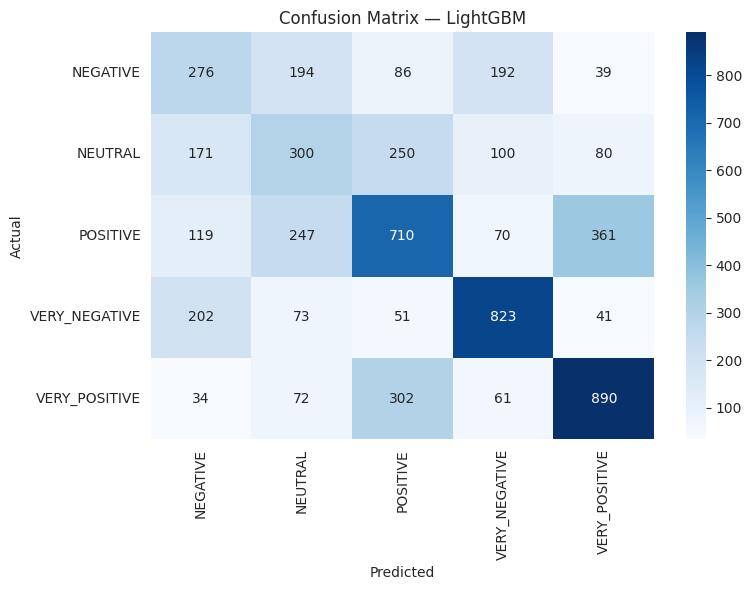

Macro AUC: 0.8152  95% CI [0.8082, 0.8217]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/LightGBM_roc_curve.png


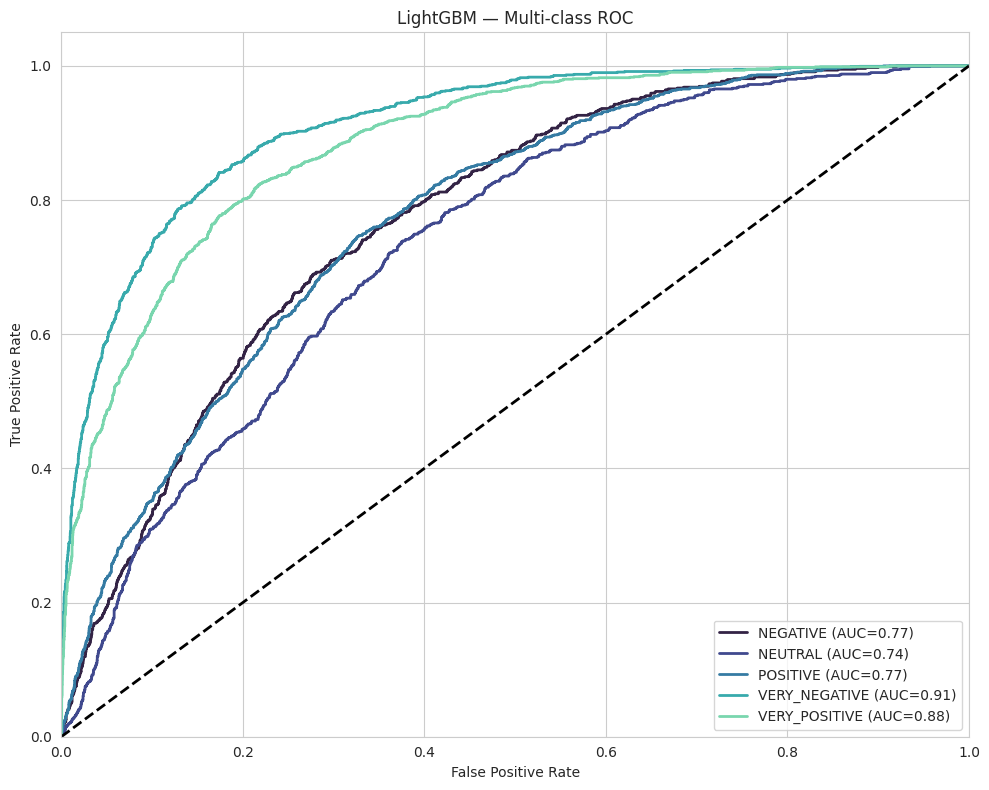

In [30]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/lightgbm_feature_importance.png


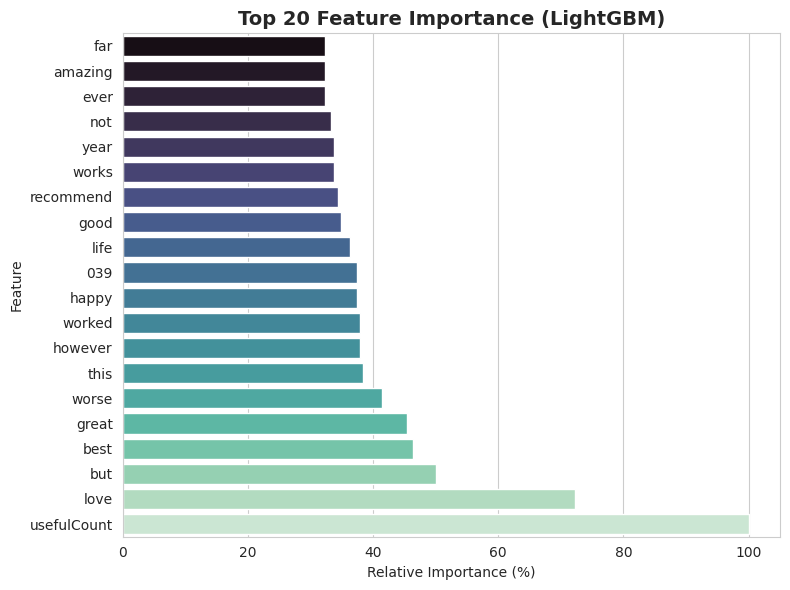

,Feature,Importance,Scaled
11166,usefulCount,198,100.000000
5528,love,143,72.222222
1985,but,99,50.000000
1702,best,92,46.464646
4168,great,90,45.454545
9852,worse,82,41.414141
8803,this,76,38.383838
4562,however,75,37.878788
9838,worked,75,37.878788
4300,happy,74,37.373737


In [31]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Support Vector Machine (SVM)

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning SVM...")
    start = time.time()

    svm_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"],   # only used by the rbf kernel
        "class_weight": ["balanced", None],
    }

    best_f1_svm, best_params_svm = 0, None

    # Tune WITHOUT probability: Platt-scaling CV is expensive and does not affect
    # model selection (which uses predict()). Enable probability only on the winner.
    for C, kernel, gamma, cw in tqdm(
        list(product(svm_grid["C"], svm_grid["kernel"], svm_grid["gamma"], svm_grid["class_weight"])),
        desc="SVM grid"
    ):
        try:
            model = SVC(
                C=C, kernel=kernel, gamma=gamma, class_weight=cw,
                probability=False, random_state=RANDOM_STATE,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_svm:
                best_f1_svm = f1
                best_params_svm = {"C": C, "kernel": kernel, "gamma": gamma, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    # Refit the best configuration ONCE with probability=True for predict_proba (ROC/AUC).
    best_model_svm = SVC(**best_params_svm, probability=True, random_state=RANDOM_STATE)
    best_model_svm.fit(X_train_tfidf, y_train_ml)

    print(f"SVM tuning: {time.time()-start:.1f}s | Best F1={best_f1_svm:.4f}")
    print(f"Best params: {best_params_svm}")

    joblib.dump(best_model_svm, MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"], "w") as f:
        json.dump(best_params_svm, f, indent=2)
else:
    print("Loading SVM from disk...")
    best_model_svm = joblib.load(MODEL_PATHS["svm"]["model"])
    print(f"Loaded SVM from {MODEL_PATHS['svm']['model']}")


Tuning SVM...


SVM grid: 100%|██████████| 24/24 [7:08:35<00:00, 1071.48s/it]


SVM tuning: 30709.0s | Best F1=0.5278
Best params: {'C': 1, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': None}


In [32]:
RETRAIN = False
if RETRAIN:
    set_seed()
    print("\nTuning SVM...")
    start = time.time()

    svm_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"],   # only used by the rbf kernel
        "class_weight": ["balanced", None],
    }

    best_f1_svm, best_params_svm = 0, None

    # Tune WITHOUT probability: Platt-scaling CV is expensive and does not affect
    # model selection (which uses predict()). Enable probability only on the winner.
    for C, kernel, gamma, cw in tqdm(
        list(product(svm_grid["C"], svm_grid["kernel"], svm_grid["gamma"], svm_grid["class_weight"])),
        desc="SVM grid"
    ):
        try:
            model = SVC(
                C=C, kernel=kernel, gamma=gamma, class_weight=cw,
                probability=False, random_state=RANDOM_STATE,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_svm:
                best_f1_svm = f1
                best_params_svm = {"C": C, "kernel": kernel, "gamma": gamma, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    # Refit the best configuration ONCE with probability=True for predict_proba (ROC/AUC).
    best_model_svm = SVC(**best_params_svm, probability=True, random_state=RANDOM_STATE)
    best_model_svm.fit(X_train_tfidf, y_train_ml)

    print(f"SVM tuning: {time.time()-start:.1f}s | Best F1={best_f1_svm:.4f}")
    print(f"Best params: {best_params_svm}")

    joblib.dump(best_model_svm, MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"], "w") as f:
        json.dump(best_params_svm, f, indent=2)
else:
    print("Loading SVM from disk...")
    best_model_svm = joblib.load(MODEL_PATHS["svm"]["model"])
    print(f"Loaded SVM from {MODEL_PATHS['svm']['model']}")

Loading SVM from disk...
Loaded SVM from /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/best_svm_model.joblib


### Step 2: Model Evaluation


Evaluation: SVM
               precision    recall  f1-score   support

     NEGATIVE     0.3450    0.3520    0.3484       787
      NEUTRAL     0.3565    0.2841    0.3162       901
     POSITIVE     0.4793    0.5773    0.5238      1507
VERY_NEGATIVE     0.7244    0.7067    0.7154      1190
VERY_POSITIVE     0.6576    0.6034    0.6293      1359

     accuracy                         0.5334      5744
    macro avg     0.5126    0.5047    0.5066      5744
 weighted avg     0.5346    0.5334    0.5319      5744

Weighted F1: 0.5319  95% CI [0.5185, 0.5446]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/SVM_confusion_matrix.png


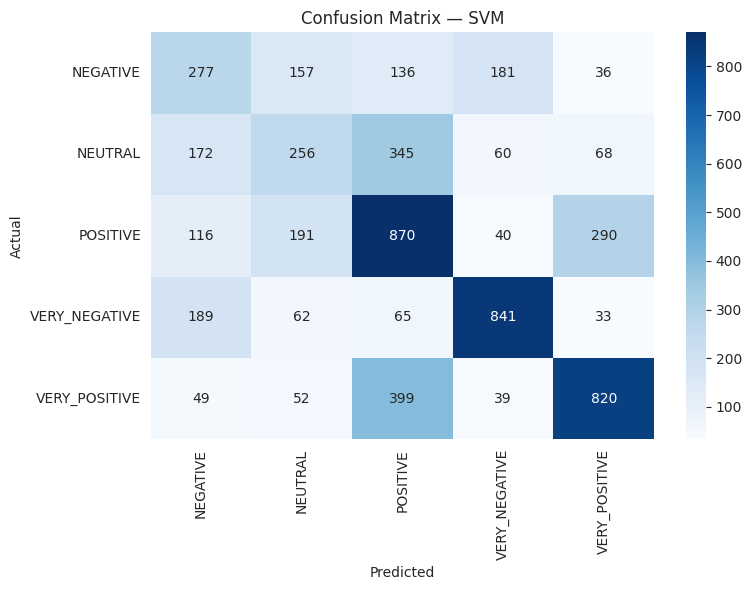

Macro AUC: 0.8266  95% CI [0.8195, 0.8330]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/SVM_roc_curve.png


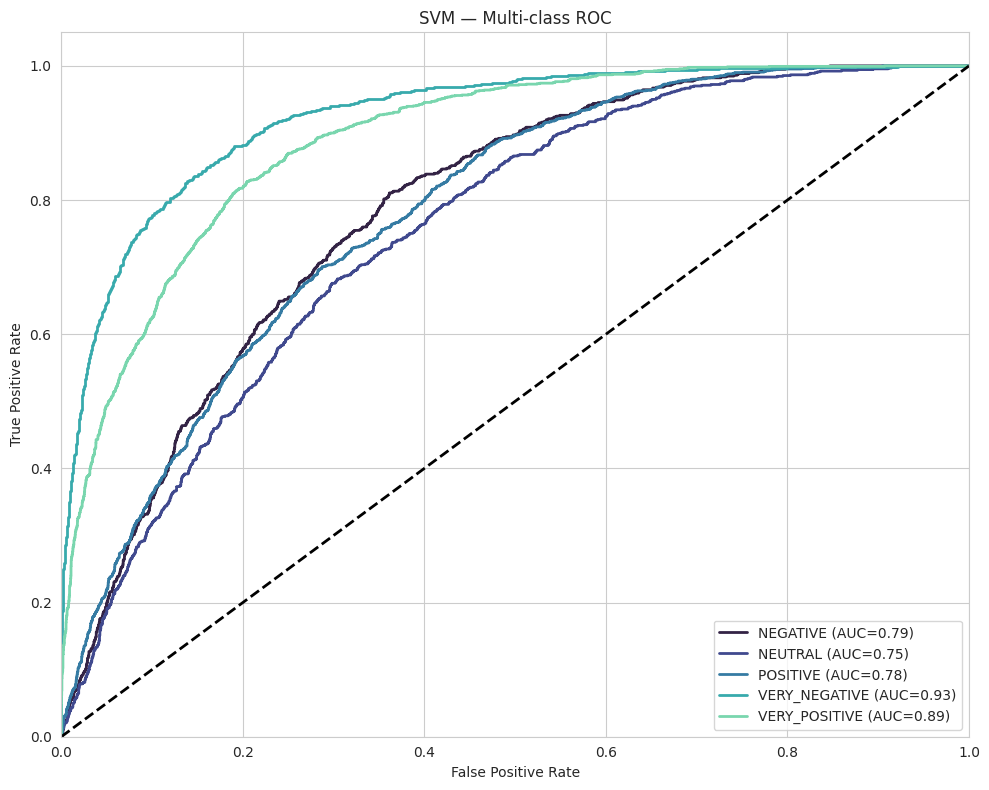

In [33]:
evaluate_ml(best_model_svm, X_test_tfidf, y_test_ml, "SVM")

## 3.5 Save Predictions for Machine Learning Models

In [34]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)
svm_pred  = best_model_svm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)
svm_proba  = best_model_svm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)
assert np.array_equal(class_names_ml, best_model_svm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred
df_pred_ml["svm_pred"]      = svm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"]  = svm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")


Saving ML predictions...
Saved ML predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/ml_models_predictions.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use augmented text (model_text) ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)


train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=17243, val=5768, test=5744
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([17243, 200]), val=torch.Size([5768, 200]), test=torch.Size([5744, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [ ]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), SEQ_MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
        "embedding_dim": (128, 256),      # was (150, 300), best=170
        "hidden_dim": (256, 512),          # was (128, 384), best=355
        "lr": (np.log10(5e-4), np.log10(1e-2)),  # narrow around best=8.6e-4
    }

    best_f1_gru, best_params_gru, best_gru = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = hp
            best_gru = model

    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.7154 | Val F1=0.0597 | Val Acc=0.1883
  Epoch 2/20 | Loss=1.7252 | Val F1=0.0889 | Val Acc=0.2342
  Epoch 3/20 | Loss=1.6724 | Val F1=0.0520 | Val Acc=0.1567
  Epoch 4/20 | Loss=1.6897 | Val F1=0.1098 | Val Acc=0.1850
  Epoch 5/20 | Loss=1.6541 | Val F1=0.1915 | Val Acc=0.2445
  Epoch 6/20 | Loss=1.6579 | Val F1=0.0536 | Val Acc=0.1564
  Epoch 7/20 | Loss=1.6628 | Val F1=0.1573 | Val Acc=0.2368
  Epoch 8/20 | Loss=1.6794 | Val F1=0.1734 | Val Acc=0.2718
  Epoch 9/20 | Loss=1.6939 | Val F1=0.1493 | Val Acc=0.2472
  Epoch 10/20 | Loss=1.6692 | Val F1=0.2122 | Val Acc=0.2429
  Epoch 11/20 | Loss=1.6687 | Val F1=0.2141 | Val Acc=0.2422
  Epoch 12/20 | Loss=1.7066 | Val F1=0.1244 | Val Acc=0.2424
  Epoch 13/20 | Loss=1.6675 | Val F1=0.1582 | Val Acc=0.2283
  Epoch 14/20 | Loss=1.6927 | Val F1=0.1116 | Val Acc=0.2389
  Epoch 15/20 | Loss=1.6570 | Val F1=0.1737 | Val Acc=0.2933


GRU Random Search:  10%|█         | 1/10 [00:18<02:48, 18.68s/it]

  Epoch 16/20 | Loss=1.6559 | Val F1=0.0949 | Val Acc=0.1749
  Early stopping at epoch 16.
  Epoch 1/20 | Loss=1.6103 | Val F1=0.1174 | Val Acc=0.2729
  Epoch 2/20 | Loss=1.6070 | Val F1=0.0904 | Val Acc=0.2349
  Epoch 3/20 | Loss=1.6063 | Val F1=0.1173 | Val Acc=0.2729
  Epoch 4/20 | Loss=1.6060 | Val F1=0.0417 | Val Acc=0.1529
  Epoch 5/20 | Loss=1.6058 | Val F1=0.0414 | Val Acc=0.1527


...

  Epoch 19/20 | Loss=1.6053 | Val F1=0.0413 | Val Acc=0.1527
  Early stopping at epoch 19.
  Epoch 1/20 | Loss=1.6105 | Val F1=0.0410 | Val Acc=0.1527
  Epoch 2/20 | Loss=1.6066 | Val F1=0.1169 | Val Acc=0.2725
  Epoch 3/20 | Loss=1.6062 | Val F1=0.0410 | Val Acc=0.1526
  Epoch 4/20 | Loss=1.6056 | Val F1=0.1173 | Val Acc=0.2727
  Epoch 5/20 | Loss=1.6058 | Val F1=0.0903 | Val Acc=0.2347
  Epoch 6/20 | Loss=1.6056 | Val F1=0.1174 | Val Acc=0.2729
  Epoch 7/20 | Loss=1.6059 | Val F1=0.0417 | Val Acc=0.1531
  Epoch 8/20 | Loss=1.6056 | Val F1=0.0432 | Val Acc=0.1527
  Epoch 9/20 | Loss=1.6057 | Val F1=0.0417 | Val Acc=0.1531
  Epoch 10/20 | Loss=1.6393 | Val F1=0.2217 | Val Acc=0.2972
  Epoch 11/20 | Loss=1.5600 | Val F1=0.2831 | Val Acc=0.3589
  Epoch 12/20 | Loss=1.4006 | Val F1=0.4224 | Val Acc=0.4390
  Epoch 13/20 | Loss=1.2026 | Val F1=0.4841 | Val Acc=0.4983
  Epoch 14/20 | Loss=0.9803 | Val F1=0.5085 | Val Acc=0.5106
  Epoch 15/20 | Loss=0.7747 | Val F1=0.5265 | Val Acc=0.5206
  E

GRU Random Search:  90%|█████████ | 9/10 [02:04<00:16, 16.35s/it]

  Epoch 20/20 | Loss=0.1656 | Val F1=0.5163 | Val Acc=0.5203
  Early stopping at epoch 20.
  Epoch 1/20 | Loss=1.6099 | Val F1=0.1169 | Val Acc=0.2725
  Epoch 2/20 | Loss=1.6078 | Val F1=0.0893 | Val Acc=0.2344
  Epoch 3/20 | Loss=1.6069 | Val F1=0.0890 | Val Acc=0.2342
  Epoch 4/20 | Loss=1.6061 | Val F1=0.0405 | Val Acc=0.1520
  Epoch 5/20 | Loss=1.6060 | Val F1=0.0405 | Val Acc=0.1522


GRU Random Search: 100%|██████████| 10/10 [02:10<00:00, 13.08s/it]

  Epoch 6/20 | Loss=1.6058 | Val F1=0.0897 | Val Acc=0.2346
  Early stopping at epoch 6.
GRU tuning: 130.8s | Best F1=0.5265
Best params: {'embedding_dim': 245, 'hidden_dim': 498, 'lr': 0.001148848116906648}


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 45/45 [00:00<00:00, 277.45it/s]


Evaluation: GRU
               precision    recall  f1-score   support

VERY_NEGATIVE     0.7470    0.6849    0.7146      1190
     NEGATIVE     0.3251    0.4536    0.3788       787
      NEUTRAL     0.3746    0.3996    0.3867       901
     POSITIVE     0.5239    0.5010    0.5122      1507
VERY_POSITIVE     0.6852    0.5813    0.6290      1359

     accuracy                         0.5357      5744
    macro avg     0.5312    0.5241    0.5243      5744
 weighted avg     0.5576    0.5357    0.5438      5744



Weighted F1: 0.5436  95% CI [0.5307, 0.5567]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/GRU_confusion_matrix.png


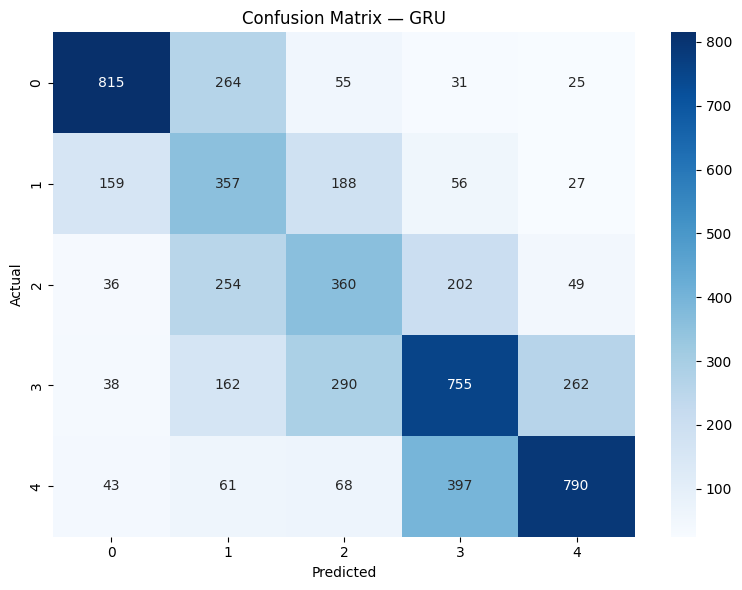

Macro AUC: 0.8325  95% CI [0.8263, 0.8391]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/GRU_roc_curve.png


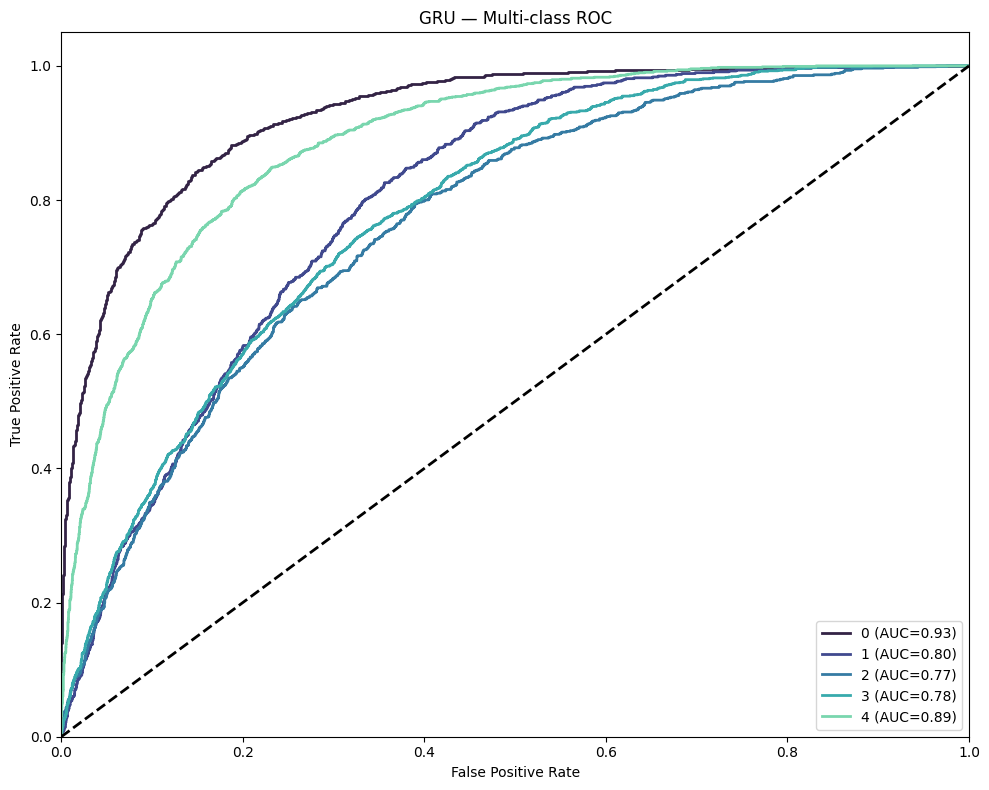

In [ ]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),
        "num_filters": (64, 256),
        "lr": (np.log10(1e-4), np.log10(1e-3)),
    }

    best_f1_cnn, best_params_cnn, best_cnn = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = hp
            best_cnn = model

    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.5451 | Val F1=0.4038 | Val Acc=0.4251
  Epoch 2/20 | Loss=1.1722 | Val F1=0.5020 | Val Acc=0.5109
  Epoch 3/20 | Loss=1.0036 | Val F1=0.5280 | Val Acc=0.5371
  Epoch 4/20 | Loss=0.8644 | Val F1=0.5255 | Val Acc=0.5451
  Epoch 5/20 | Loss=0.7608 | Val F1=0.5264 | Val Acc=0.5322
  Epoch 6/20 | Loss=0.6625 | Val F1=0.5341 | Val Acc=0.5390
  Epoch 7/20 | Loss=0.5649 | Val F1=0.5426 | Val Acc=0.5532
  Epoch 8/20 | Loss=0.4814 | Val F1=0.5372 | Val Acc=0.5362
  Epoch 9/20 | Loss=0.4152 | Val F1=0.5570 | Val Acc=0.5562
  Epoch 10/20 | Loss=0.3451 | Val F1=0.5505 | Val Acc=0.5484
  Epoch 11/20 | Loss=0.2954 | Val F1=0.5552 | Val Acc=0.5661
  Epoch 12/20 | Loss=0.2541 | Val F1=0.5537 | Val Acc=0.5584
  Epoch 13/20 | Loss=0.2388 | Val F1=0.5394 | Val Acc=0.5513


CNN Random Search:  10%|█         | 1/10 [00:05<00:47,  5.25s/it]

  Epoch 14/20 | Loss=0.2104 | Val F1=0.5490 | Val Acc=0.5593
  Early stopping at epoch 14.
  Epoch 1/20 | Loss=1.6450 | Val F1=0.3449 | Val Acc=0.3682
  Epoch 2/20 | Loss=1.4538 | Val F1=0.3702 | Val Acc=0.3903
  Epoch 3/20 | Loss=1.3244 | Val F1=0.4169 | Val Acc=0.4371
  Epoch 4/20 | Loss=1.2259 | Val F1=0.4831 | Val Acc=0.4912
  Epoch 5/20 | Loss=1.1551 | Val F1=0.5125 | Val Acc=0.5153
  Epoch 6/20 | Loss=1.0889 | Val F1=0.4963 | Val Acc=0.5038
  Epoch 7/20 | Loss=1.0356 | Val F1=0.5191 | Val Acc=0.5298
  Epoch 8/20 | Loss=0.9828 | Val F1=0.5234 | Val Acc=0.5253
  Epoch 9/20 | Loss=0.9433 | Val F1=0.5267 | Val Acc=0.5206
  Epoch 10/20 | Loss=0.8965 | Val F1=0.5274 | Val Acc=0.5362
  Epoch 11/20 | Loss=0.8537 | Val F1=0.5357 | Val Acc=0.5397
  Epoch 12/20 | Loss=0.8229 | Val F1=0.5400 | Val Acc=0.5510
  Epoch 13/20 | Loss=0.7806 | Val F1=0.5462 | Val Acc=0.5518
  Epoch 14/20 | Loss=0.7443 | Val F1=0.5490 | Val Acc=0.5513
  Epoch 15/20 | Loss=0.7130 | Val F1=0.5534 | Val Acc=0.5558
  E

...

  Epoch 20/20 | Loss=0.5359 | Val F1=0.5632 | Val Acc=0.5641
  Epoch 1/20 | Loss=1.5956 | Val F1=0.4153 | Val Acc=0.4159
  Epoch 2/20 | Loss=1.3219 | Val F1=0.4638 | Val Acc=0.4750
  Epoch 3/20 | Loss=1.1650 | Val F1=0.4935 | Val Acc=0.5088
  Epoch 4/20 | Loss=1.0592 | Val F1=0.5003 | Val Acc=0.5246
  Epoch 5/20 | Loss=0.9661 | Val F1=0.5157 | Val Acc=0.5251
  Epoch 6/20 | Loss=0.8910 | Val F1=0.5239 | Val Acc=0.5361
  Epoch 7/20 | Loss=0.8152 | Val F1=0.5426 | Val Acc=0.5494
  Epoch 8/20 | Loss=0.7530 | Val F1=0.5420 | Val Acc=0.5524
  Epoch 9/20 | Loss=0.6930 | Val F1=0.5409 | Val Acc=0.5522
  Epoch 10/20 | Loss=0.6407 | Val F1=0.5357 | Val Acc=0.5452
  Epoch 11/20 | Loss=0.5891 | Val F1=0.5489 | Val Acc=0.5505
  Epoch 12/20 | Loss=0.5447 | Val F1=0.5617 | Val Acc=0.5602
  Epoch 13/20 | Loss=0.5062 | Val F1=0.5522 | Val Acc=0.5527
  Epoch 14/20 | Loss=0.4676 | Val F1=0.5558 | Val Acc=0.5607
  Epoch 15/20 | Loss=0.4394 | Val F1=0.5470 | Val Acc=0.5518
  Epoch 16/20 | Loss=0.4073 | Val

CNN Random Search:  90%|█████████ | 9/10 [00:50<00:06,  6.19s/it]

  Epoch 20/20 | Loss=0.3120 | Val F1=0.5550 | Val Acc=0.5603
  Epoch 1/20 | Loss=1.6861 | Val F1=0.3171 | Val Acc=0.3402
  Epoch 2/20 | Loss=1.5652 | Val F1=0.3697 | Val Acc=0.3811
  Epoch 3/20 | Loss=1.4750 | Val F1=0.3969 | Val Acc=0.4098
  Epoch 4/20 | Loss=1.4036 | Val F1=0.4376 | Val Acc=0.4435
  Epoch 5/20 | Loss=1.3356 | Val F1=0.4332 | Val Acc=0.4476
  Epoch 6/20 | Loss=1.2845 | Val F1=0.4685 | Val Acc=0.4743
  Epoch 7/20 | Loss=1.2350 | Val F1=0.4664 | Val Acc=0.4704
  Epoch 8/20 | Loss=1.1974 | Val F1=0.4868 | Val Acc=0.4884
  Epoch 9/20 | Loss=1.1672 | Val F1=0.4904 | Val Acc=0.4898
  Epoch 10/20 | Loss=1.1334 | Val F1=0.5038 | Val Acc=0.5073
  Epoch 11/20 | Loss=1.0987 | Val F1=0.4913 | Val Acc=0.4939
  Epoch 12/20 | Loss=1.0755 | Val F1=0.4970 | Val Acc=0.5035
  Epoch 13/20 | Loss=1.0486 | Val F1=0.5099 | Val Acc=0.5147
  Epoch 14/20 | Loss=1.0224 | Val F1=0.5116 | Val Acc=0.5081
  Epoch 15/20 | Loss=0.9980 | Val F1=0.5155 | Val Acc=0.5166
  Epoch 16/20 | Loss=0.9704 | Val

CNN Random Search: 100%|██████████| 10/10 [00:56<00:00,  5.67s/it]

  Epoch 20/20 | Loss=0.8841 | Val F1=0.5242 | Val Acc=0.5291
CNN tuning: 56.7s | Best F1=0.5661
Best params: {'embedding_dim': 287, 'num_filters': 245, 'lr': 0.00018953847119167257}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 45/45 [00:00<00:00, 1025.05it/s]


Evaluation: CNN
               precision    recall  f1-score   support

VERY_NEGATIVE     0.7342    0.7218    0.7280      1190
     NEGATIVE     0.3856    0.3685    0.3769       787
      NEUTRAL     0.3812    0.3685    0.3747       901
     POSITIVE     0.5263    0.5846    0.5539      1507
VERY_POSITIVE     0.6891    0.6475    0.6677      1359

     accuracy                         0.5644      5744
    macro avg     0.5433    0.5382    0.5402      5744
 weighted avg     0.5658    0.5644    0.5645      5744



Weighted F1: 0.5646  95% CI [0.5512, 0.5771]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/CNN_confusion_matrix.png


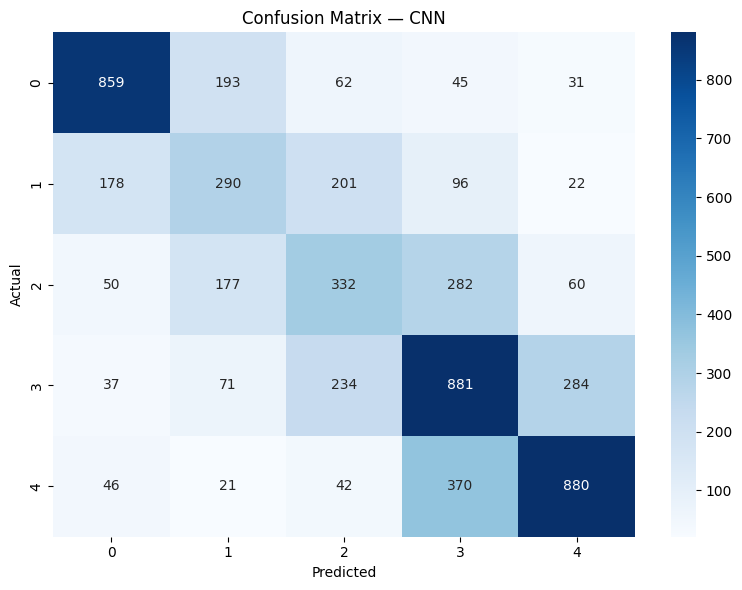

Macro AUC: 0.8522  95% CI [0.8462, 0.8584]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/CNN_roc_curve.png


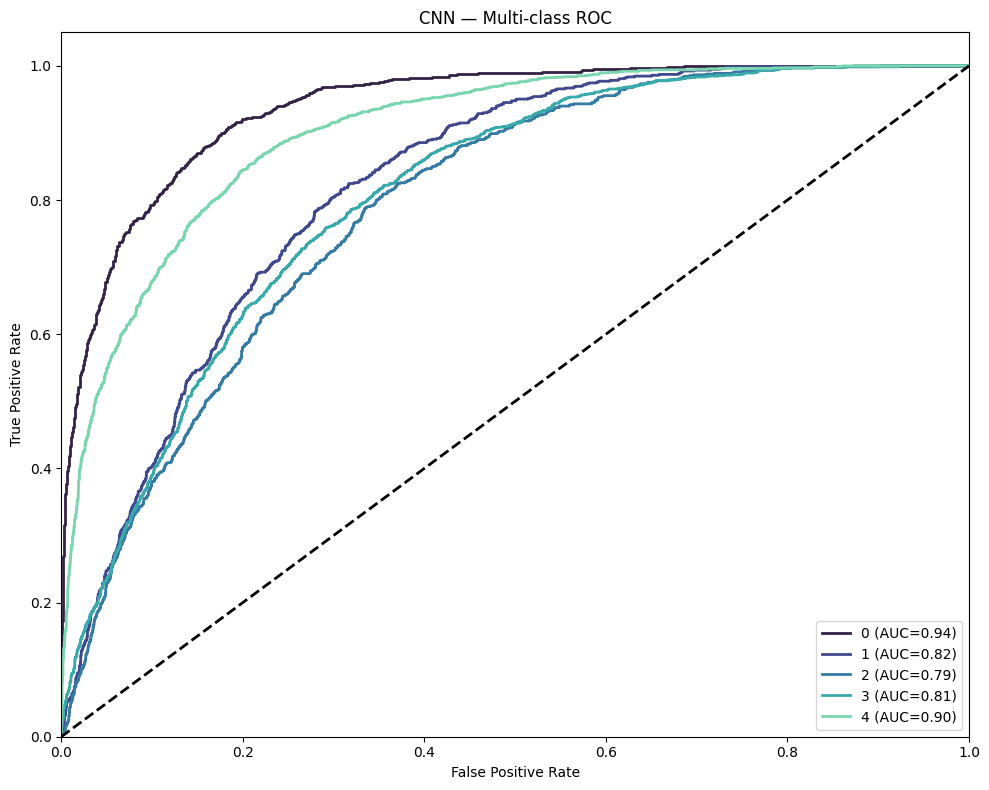

In [ ]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

ALBERT tokens: train=torch.Size([17243, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
else:
    print("Loading ALBERT from disk...")
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.3488 | Val F1=0.6101
  Epoch 2/9 | Loss=0.8364 | Val F1=0.6624
  Epoch 3/9 | Loss=0.6670 | Val F1=0.6692
  Epoch 4/9 | Loss=0.5172 | Val F1=0.6862
  Epoch 5/9 | Loss=0.3683 | Val F1=0.6829
  Epoch 6/9 | Loss=0.2414 | Val F1=0.6964
  Epoch 7/9 | Loss=0.1507 | Val F1=0.6931
  Epoch 8/9 | Loss=0.0917 | Val F1=0.6936
  Epoch 9/9 | Loss=0.0681 | Val F1=0.6934
  Early stopping at epoch 9.


ALBERT Random Search: 100%|██████████| 10/10 [28:48<00:00, 172.81s/it]

ALBERT tuning: 1728.1s | Best F1=0.6964
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 45/45 [00:03<00:00, 13.26it/s]



Evaluation: ALBERT
               precision    recall  f1-score   support

VERY_NEGATIVE     0.8779    0.7857    0.8293      1190
     NEGATIVE     0.5385    0.6404    0.5850       787
      NEUTRAL     0.5467    0.5849    0.5651       901
     POSITIVE     0.6387    0.6662    0.6522      1507
VERY_POSITIVE     0.7970    0.7079    0.7498      1359

     accuracy                         0.6845      5744
    macro avg     0.6798    0.6770    0.6763      5744
 weighted avg     0.6975    0.6845    0.6891      5744

Weighted F1: 0.6894  95% CI [0.6781, 0.7008]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/ALBERT_confusion_matrix.png


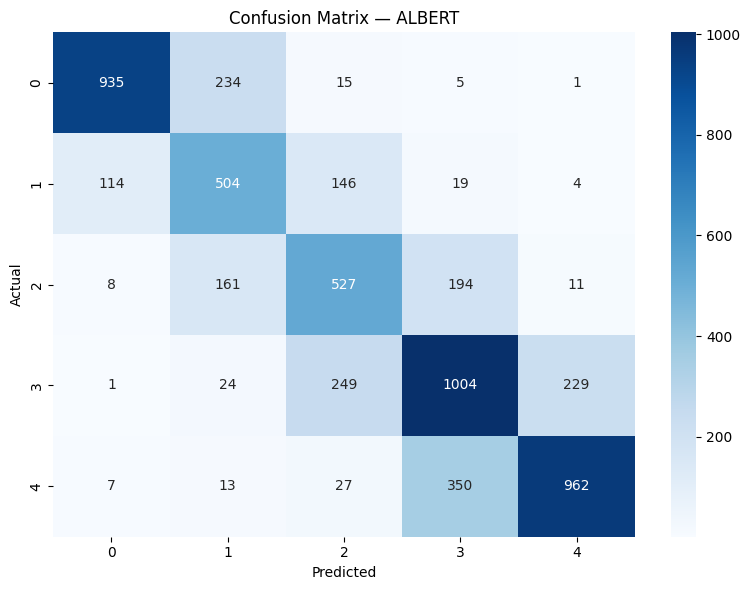

Macro AUC: 0.9183  95% CI [0.9139, 0.9227]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/ALBERT_roc_curve.png


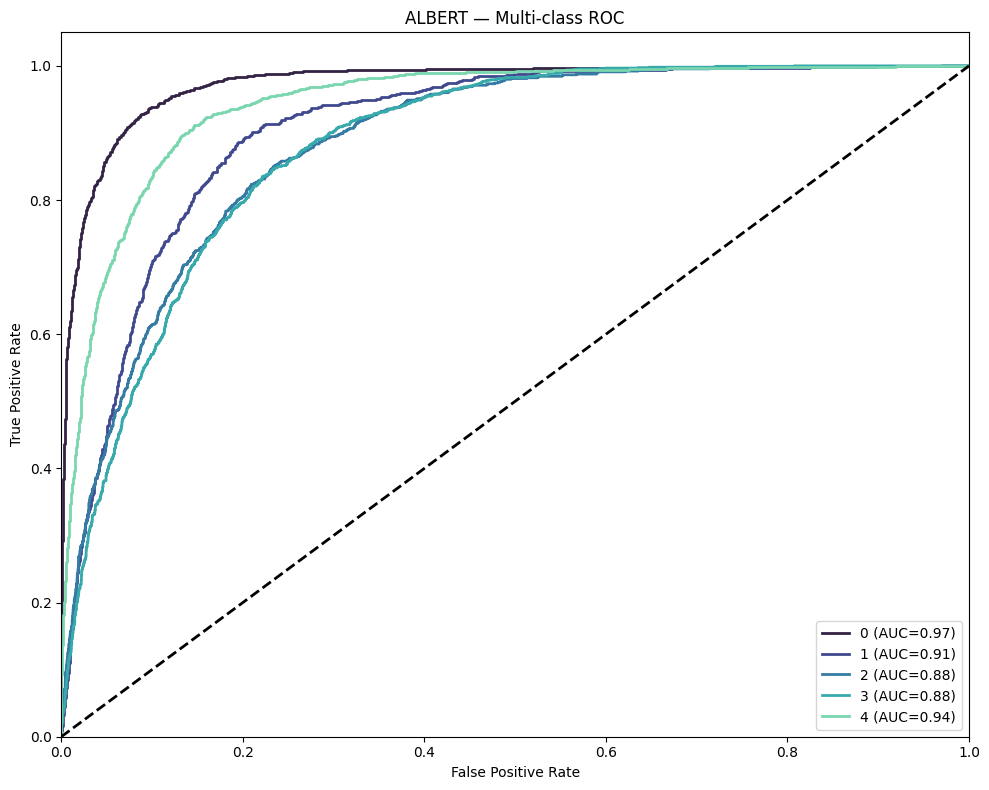

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [ ]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
]:
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")


Saving DL predictions...
Saved DL predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/dl_models_predictions.csv


# 5. Model Comparison

In [35]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

df_merged = pd.merge(df_ml_pred, df_dl_pred, on=["id", "true_label", "true_label_id"],
                     suffixes=("_ml", "_dl"))
print(f"Merged: {df_merged.shape[0]} rows")

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":     label_encoder.transform(df_merged["lr_pred"].values),
    "RF":     label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":   label_encoder.transform(df_merged["lgbm_pred"].values),
    "SVM":    label_encoder.transform(df_merged["svm_pred"].values),
    "GRU":    df_merged["gru_pred_id"].values,
    "CNN":    df_merged["cnn_pred_id"].values,
    "ALBERT": df_merged["albert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": res.statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 5744 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong  statistic        p_raw    winner_raw  p_corrected significant
     LR      RF          2275      817      656        1996  17.379498 3.061102e-05       LR > RF 6.428314e-04         Yes
     LR    LGBM          2336      756      663        1989   5.964764 1.459455e-02     LR > LGBM 3.064856e-01          No
     LR     SVM          2727      365      337        2315   1.038462 3.081795e-01  Inconclusive 1.000000e+00          No
     LR     GRU          2166      926      911        1741   0.106696 7.439379e-01  Inconclusive 1.000000e+00          No
     LR     CNN          2404      688      838        1814  14.548493 1.365979e-04      CNN > LR 2.868555e-03         Yes
     LR  ALBERT          2440      652     1492        1160 328.321362 2.230487e-73   ALBERT > LR 4.684023e-72         Yes
     RF    LGBM          2288

# 6. Add Additional Metric: MAE \& QWK

In [36]:
# ============================================================
# Ordinal metrics for this notebook:
# MAE and Quadratic Weighted Kappa (QWK)
# with 95% bootstrap CI, 1000 bootstrap samples
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import cohen_kappa_score

N_BOOT = 1000
BOOT_SEED = 20260510

OUTPUT_PATH = Path(OUTPUT_PATH)

PREDICTION_FILES = [
    OUTPUT_PATH / "ml_models_predictions.csv",
    OUTPUT_PATH / "dl_models_predictions.csv",
]

# Explicit ordinal mapping from your notebook config
LABEL_TO_ID = {label: i for i, label in enumerate(CLASS_NAMES)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

def to_ordinal_array(x):
    s = pd.Series(x)

    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float).astype(int).to_numpy()

    z = s.astype(str).str.strip().str.upper()
    mapped = z.map(LABEL_TO_ID)

    if mapped.isna().any():
        bad = sorted(z[mapped.isna()].dropna().unique().tolist())[:20]
        raise ValueError(f"Unmapped label values: {bad}")

    return mapped.astype(int).to_numpy()

def mae_score(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def qwk_score(y_true, y_pred):
    labels = np.arange(len(CLASS_NAMES))
    return float(cohen_kappa_score(y_true, y_pred, labels=labels, weights="quadratic"))

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=20260510):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    point = metric_fn(y_true, y_pred)
    boot = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[b] = metric_fn(y_true[idx], y_pred[idx])

    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    return point, float(lo), float(hi)

def get_true_column(df):
    if "true_label_id" in df.columns:
        return "true_label_id"
    if "true_label" in df.columns:
        return "true_label"
    raise ValueError("Could not find true-label column. Expected true_label_id or true_label.")

def get_prediction_columns(df):
    # ML: lr_pred, rf_pred, lgbm_pred
    return [
        c for c in df.columns
        if c.endswith("_pred") and not c.endswith("_pred_id")
    ]

rows = []

for pred_path in PREDICTION_FILES:
    if not pred_path.exists():
        print(f"Skipping missing file: {pred_path}")
        continue

    print(f"Reading: {pred_path}")
    df_pred = pd.read_csv(pred_path)

    true_col = get_true_column(df_pred)
    y_true = to_ordinal_array(df_pred[true_col])

    pred_cols = get_prediction_columns(df_pred)
    if not pred_cols:
        raise ValueError(f"No prediction columns ending in _pred found in {pred_path}")

    for pred_col in pred_cols:
        y_pred = to_ordinal_array(df_pred[pred_col])
        model = pred_col.replace("_pred", "")

        mae, mae_lo, mae_hi = bootstrap_ci(
            y_true,
            y_pred,
            mae_score,
            n_boot=N_BOOT,
            seed=BOOT_SEED,
        )

        qwk, qwk_lo, qwk_hi = bootstrap_ci(
            y_true,
            y_pred,
            qwk_score,
            n_boot=N_BOOT,
            seed=BOOT_SEED + 17,
        )

        rows.append({
            "prediction_file": pred_path.name,
            "model": model,
            "n": len(df_pred),
            "mae": mae,
            "mae_ci_lower": mae_lo,
            "mae_ci_upper": mae_hi,
            "qwk": qwk,
            "qwk_ci_lower": qwk_lo,
            "qwk_ci_upper": qwk_hi,
        })

ordinal_metrics = pd.DataFrame(rows)

display(ordinal_metrics)

save_path = OUTPUT_PATH / "ordinal_mae_qwk_bootstrap.csv"
ordinal_metrics.to_csv(save_path, index=False)
print(f"Saved: {save_path}")


Reading: /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/ml_models_predictions.csv
Reading: /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/dl_models_predictions.csv


,prediction_file,model,n,mae,mae_ci_lower,mae_ci_upper,qwk,qwk_ci_lower,qwk_ci_upper
0,ml_models_predictions.csv,lr,5744,0.662430,0.639271,0.685241,0.715274,0.698824,0.732602
1,ml_models_predictions.csv,rf,5744,0.761490,0.736072,0.786912,0.665389,0.648506,0.682062
2,ml_models_predictions.csv,lgbm,5744,0.690982,0.665564,0.712400,0.703053,0.687247,0.719540
3,ml_models_predictions.csv,svm,5744,0.656337,0.632486,0.677411,0.721772,0.706112,0.737234
4,dl_models_predictions.csv,gru,5744,0.628656,0.606711,0.649382,0.738975,0.724053,0.755269
5,dl_models_predictions.csv,cnn,5744,0.585655,0.563714,0.606028,0.761175,0.746950,0.775259
6,dl_models_predictions.csv,albert,5744,0.345752,0.331650,0.359340,0.897756,0.890483,0.904478


Saved: /content/drive/MyDrive/NLP_Projects/03_DrugReview_pilot/R0/T42_mini4o_Text_Metadata/outputs/ordinal_mae_qwk_bootstrap.csv
